# Conveyor Belt Visual RAG: SigLIP2 + ChromaDB + Qwen3-VL + Sensor

컨베이어 벨트 영상 데이터로 **Visual RAG** 파이프라인을 단계별로 구현합니다.
이미지 임베딩·벡터 검색·센서 메타데이터 연계·Qwen3-VL 분석을 **노트북 셀**에서 직접 실행합니다.

## 전체 흐름

```
Conveyor Video (Conveyor_Belt_Sample.zip)
       ↓
OpenCV Frame 추출 → frame0001.jpg ...
       ↓
SigLIP2 Embedding 생성
       ↓
ChromaDB 저장 (Embedding + 센서 Metadata)
       ▲
sensor.csv (가상 생성)
       ↓
한글 Query → SigLIP2 → Top-k Search
       ↓
Qwen3-VL 분석 (이미지 + 센서 수치)
```

| 단계 | 역할 |
|------|------|
| **OpenCV** | 비디오에서 프레임 추출 |
| **sensor.csv** | frame별 temp/rpm/vibration/status 가상 생성 |
| **SigLIP2** | 이미지·텍스트 임베딩 (한글 검색) |
| **ChromaDB** | 임베딩 + 센서 메타데이터 저장·검색 |
| **Qwen3-VL** | 검색 프레임 + 센서를 종합한 이상 분석 |

### Visual RAG란?

- **RAG(Retrieval-Augmented Generation)**: 질문에 맞는 정보를 먼저 **검색**하고, 그 결과를 생성 모델에 넣어 답을 만드는 방식입니다.
- **Visual RAG**: 검색 대상이 **텍스트 문서**가 아니라 **이미지(또는 영상 프레임)** 인 RAG입니다.
- 이 노트북은 **검색(Retriever: SigLIP2 + ChromaDB)** 과 **생성(Generator: Qwen3-VL)** 을 분리합니다.
  - 검색은 가볍고 빠르게, 생성은 정밀하게 처리합니다.

### 왜 센서 데이터를 함께 쓰나?

이미지만 보면 놓치기 쉬운 **온도·진동·RPM** 같은 수치를 메타데이터로 연결하면,
검색 결과와 AI 분석 모두에서 **시각 + 계측** 정보를 함께 활용할 수 있습니다.

### 모듈 소스 참조

셀 안에 구현된 로직과 동일한 Python 모듈이 `conveyor_analyze/`에 정리되어 있습니다.

📄 **[00_모듈_참조.md](00_모듈_참조.md)** — 경로별 파일 목록 + 기능 요약

| 대응 모듈 | 경로 |
|-----------|------|
| 경로·모델 상수 | `conveyor_analyze/conveyor_rag/config.py` |
| SigLIP2 임베딩 | `conveyor_analyze/conveyor_rag/encoder.py` |
| sensor.csv | `conveyor_analyze/conveyor_rag/sensor.py` |
| ChromaDB | `conveyor_analyze/conveyor_rag/store.py` |
| Qwen3-VL 분석 | `conveyor_analyze/conveyor_rag/analyzer.py` |
| 한글 차트 | `conveyor_analyze/conveyor_rag/plot_utils.py` |

## 0. 환경 설정

이 단계에서는 라이브러리를 불러오고, 데이터 경로·모델 이름·GPU 여부를 설정합니다.

| 기술 | 설명 |
|------|------|
| **PyTorch** | 딥러닝 모델(SigLIP2, Qwen3-VL) 실행. `cuda` 사용 시 GPU 가속 |
| **OpenCV** | 비디오 파일 읽기, 프레임 이미지 저장 |
| **ChromaDB** | 벡터(임베딩)를 디스크에 저장하고 유사도 검색 |
| **transformers** | Hugging Face 모델(SigLIP2, Qwen3-VL) 로드 |
| **matplotlib** | 프레임·검색 결과·센서 차트 시각화 |

> 첫 실행 시 Hugging Face에서 모델 가중치를 다운로드합니다. 네트워크와 디스크 여유가 필요합니다.

In [1]:
# !pip install -r requirements.txt
# 프로젝트 루트(09_Visual_RAG)에서 실행, Conveyor_Belt_Sample.zip 필요
# [설명] 위 주석을 해제하면 현재 Jupyter 커널의 Python에 패키지를 설치합니다.

In [2]:
import csv       # sensor.csv 저장
import gc         # GPU 메모리 해제 시 객체 정리
import json
import os         # 폰트 파일 경로 확인 (Linux/Colab)
import platform   # Windows / macOS / Linux 판별 (한글 폰트 설정)
import random
import shutil     # ZIP 압축 해제 폴더 삭제
import subprocess # Colab에서 나눔폰트 설치 시 사용
import zipfile    # Conveyor_Belt_Sample.zip 해제
from pathlib import Path  # OS에 맞는 경로 처리

import chromadb   # 벡터 DB — 임베딩 저장·유사도 검색
import cv2        # OpenCV — 비디오 읽기, 프레임 저장
import matplotlib.font_manager as fm  # 시스템 폰트 목록 조회
import matplotlib.pyplot as plt       # 이미지·차트 시각화
import numpy as np
import pandas as pd       # sensor.csv 표·차트
import torch              # GPU 텐서 연산
from IPython.display import display  # 노트북에서 DataFrame 예쁘게 출력
from PIL import Image     # 이미지 로드 (RGB 변환)
from tqdm import tqdm     # 인덱싱 진행률 표시
from transformers import AutoModel, AutoProcessor, Qwen3VLForConditionalGeneration


def setup_korean_matplotlib():
    """Windows / Colab / macOS matplotlib 한글 폰트 설정."""
    # matplotlib 기본 폰트는 영어만 지원 → 한글 제목이 □□□ 로 깨짐
    # OS별로 설치된 한글 폰트를 찾아 rcParams에 등록합니다.
    system = platform.system()
    chosen = None

    def font_names():
        return {f.name for f in fm.fontManager.ttflist}

    if system == "Windows":
        for name in ("Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"):
            if name in font_names():
                chosen = name
                break
    elif system == "Darwin":
        for name in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic"):
            if name in font_names():
                chosen = name
                break
    else:
        nanum_paths = [
            "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
            "/usr/share/fonts/nanum/NanumGothic.ttf",
        ]
        if not any(os.path.exists(p) for p in nanum_paths):
            try:
                subprocess.run(
                    ["apt-get", "-qq", "install", "-y", "fonts-nanum"],
                    check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
                )
            except Exception:
                pass
        for path in nanum_paths:
            if os.path.exists(path):
                fm.fontManager.addfont(path)
                chosen = fm.FontProperties(fname=path).get_name()
                break
        if chosen is None:
            for name in ("NanumGothic", "NanumBarunGothic", "UnDotum"):
                if name in font_names():
                    chosen = name
                    break

    if chosen:
        plt.rcParams["font.family"] = chosen
    else:
        print("경고: 한글 폰트를 찾지 못했습니다.")
    # 유니코드 마이너스(−) 대신 ASCII 하이픈(-) → 음수 축 레이블 깨짐 방지
    plt.rcParams["axes.unicode_minus"] = False
    return chosen

# --- 경로 (노트북 실행 위치 = 프로젝트 루트, ZIP과 동일 폴더) ---
ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data" / "conveyor"
FRAMES_DIR = DATA_DIR / "frames"       # frame0001.jpg ...
VIDEO_DIR = DATA_DIR / "video"         # ZIP 해제·원본 mp4
CHROMA_DIR = DATA_DIR / "chroma_db"    # ChromaDB 영구 저장
SENSOR_CSV = DATA_DIR / "sensor.csv"   # 프레임별 가상 센서
ZIP_PATH = ROOT / "Conveyor_Belt_Sample.zip"

for d in [DATA_DIR, FRAMES_DIR, VIDEO_DIR, CHROMA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"Conveyor_Belt_Sample.zip 없음: {ZIP_PATH}\n"
        f"현재 폴더({ROOT})에 ZIP 파일을 배치한 뒤 다시 실행하세요."
    )

# --- 하이퍼파라미터 ---
SIGLIP2_MODEL_ID = "google/siglip2-so400m-patch14-384"  # 이미지·텍스트 임베딩 (한글 검색 강함)
# VRAM 8~12GB: 2B 권장 / 16GB+: 4B 가능
QWEN_MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"
# QWEN_MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"
COLLECTION_NAME = "conveyor_siglip2"   # ChromaDB 컬렉션 이름
SIGLIP2_BATCH_SIZE = 8                 # GPU 메모리에 맞게 조절 (OOM 시 4로 줄이기)
TOP_K = 4           # 검색 Top-k (분석도 동일 개수 전체 수행)
NUM_FRAMES = 20                        # 비디오에서 추출할 최대 프레임 수
FRAME_INTERVAL_SEC = 1.0               # 1초마다 1프레임 추출

# 모델 핸들 — 나중에 GPU 메모리 해제 시 None으로 설정
siglip_encoder = None
qwen_model = None
qwen_processor = None

device = "cuda" if torch.cuda.is_available() else "cpu"
_korean_font = setup_korean_matplotlib()
print(f"ROOT: {ROOT}")
print(f"Device: {device}")
print(f"matplotlib 한글 폰트: {_korean_font or '미설정'}")
print(f"ZIP: {ZIP_PATH} ({'존재' if ZIP_PATH.exists() else '없음'})")
print(f"Qwen 모델: {QWEN_MODEL_ID}")

ROOT: C:\MyCursorLab\09_Visual_RAG
Device: cuda
matplotlib 한글 폰트: Malgun Gothic
ZIP: C:\MyCursorLab\09_Visual_RAG\Conveyor_Belt_Sample.zip (존재)
Qwen 모델: Qwen/Qwen3-VL-2B-Instruct


## 1. Conveyor Video → OpenCV Frame 추출

현재 폴더의 `Conveyor_Belt_Sample.zip`을 압축 해제하고 OpenCV로 프레임을 추출합니다.

https://github.com/supervisely-ecosystem/conveyor-belt-detection-static-camera

| 기술 | 설명 |
|------|------|
| **zipfile** | ZIP 안의 비디오·어노테이션 파일을 디스크에 풀기 |
| **OpenCV VideoCapture** | mp4/avi 등 비디오를 프레임 단위로 읽기 |
| **프레임 샘플링** | 매 프레임이 아니라 `FRAME_INTERVAL_SEC`(1초) 간격으로 저장 → 용량·처리 시간 절약 |

**왜 프레임으로 나누나?**  
VLM·임베딩 모델은 **이미지 한 장** 단위로 동작합니다. 영상 전체를 한 번에 넣을 수 없으므로,
대표 순간을 JPG로 저장한 뒤 각 프레임을 개별 문서처럼 인덱싱합니다.

출력 파일명: `frame0001.jpg`, `frame0002.jpg`, ...

In [3]:
def find_video(directory: Path) -> Path | None:
    """폴더(하위 포함)에서 첫 번째 비디오 파일 경로를 찾습니다."""
    for ext in ("*.mp4", "*.avi", "*.mov", "*.mkv"):
        found = list(directory.glob(ext))
        if found:
            return found[0]
    for sub in directory.rglob("*"):
        if sub.suffix.lower() in {".mp4", ".avi", ".mov", ".mkv"}:
            return sub
    return None


def extract_zip(zip_path: Path) -> Path:
    """ZIP 압축 해제 후 내부 비디오 파일 경로를 반환합니다."""
    extract_dir = VIDEO_DIR / "extracted"
    if extract_dir.exists():
        shutil.rmtree(extract_dir)  # 이전 실행 잔여 파일 제거
    extract_dir.mkdir(parents=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    video = find_video(extract_dir)
    if video is None:
        raise FileNotFoundError(f"ZIP 내 비디오 없음: {zip_path}")
    return video


def extract_frames(video_path: Path, max_frames: int = NUM_FRAMES) -> list[Path]:
    """비디오에서 일정 간격으로 프레임을 추출해 JPG로 저장합니다."""
    # 기존 프레임 삭제 — 재실행 시 이전 결과와 섞이지 않도록
    for old in FRAMES_DIR.glob("frame*.jpg"):
        old.unlink()

    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 5.0  # FPS 정보 없으면 5로 가정
    step = max(int(fps * FRAME_INTERVAL_SEC), 1)  # 몇 프레임마다 1장 저장할지

    saved, frame_idx, save_idx = [], 0, 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % step == 0:
            save_idx += 1
            out = FRAMES_DIR / f"frame{save_idx:04d}.jpg"
            cv2.imwrite(str(out), frame)  # BGR 그대로 저장 (미리보기 시 RGB 변환)
            saved.append(out)
            if save_idx >= max_frames:
                break
        frame_idx += 1
    cap.release()
    return saved


video_path = extract_zip(ZIP_PATH)
print(f"ZIP 해제 → {video_path}")
frame_paths = extract_frames(video_path)
print(f"프레임 {len(frame_paths)}장 추출 완료: {FRAMES_DIR}")

ZIP 해제 → C:\MyCursorLab\09_Visual_RAG\data\conveyor\video\extracted\ds0\video\conveyor.mp4
프레임 20장 추출 완료: C:\MyCursorLab\09_Visual_RAG\data\conveyor\frames


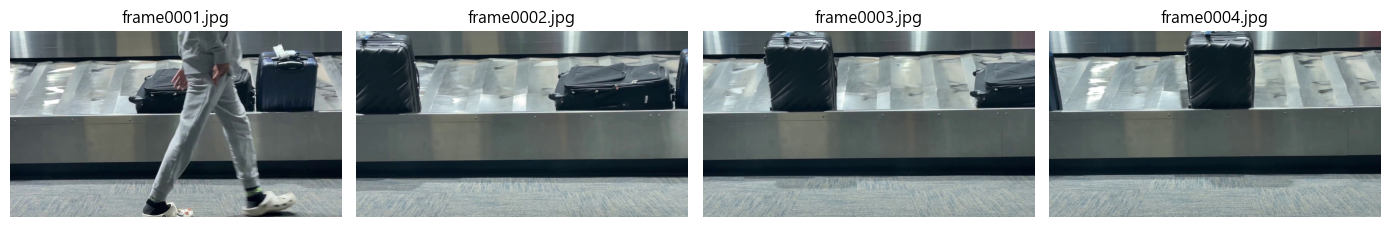

In [4]:
# 추출된 프레임 미리보기
setup_korean_matplotlib()  # 한글 제목 깨짐 방지
fig, axes = plt.subplots(1, min(4, len(frame_paths)), figsize=(14, 3))
if len(frame_paths) == 1:
    axes = [axes]  # 프레임 1장일 때 axes가 단일 객체이므로 리스트로 통일
for ax, fp in zip(axes, frame_paths[:4]):
    # OpenCV는 BGR, matplotlib은 RGB → cvtColor로 변환 후 imshow
    ax.imshow(cv2.cvtColor(cv2.imread(str(fp)), cv2.COLOR_BGR2RGB))
    ax.set_title(fp.name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. 가상 센서 CSV 생성 (sensor.csv)

프레임마다 `temp`, `rpm`, `vibration`, `current`, `speed`, `status`를 자동 생성합니다.
frame0001~0004는 아래 시드 값을 그대로 사용합니다.

| frame | temp | rpm | vibration | status |
|-------|------|-----|-----------|--------|
| 0001 | 38.2 | 1150 | 0.08 | Normal |
| 0003 | 45.3 | 1230 | 0.31 | Warning |
| 0004 | 48.8 | 1260 | 0.45 | Fault |

### 왜 가상 센서를 만드나?

실제 공장에서는 PLC·IoT 센서가 초당 수백 개 수치를 냅니다.
실습에서는 **프레임 번호 ↔ 센서 행**을 1:1로 맞춘 CSV를 만들어,
ChromaDB 메타데이터와 Qwen3-VL 분석에 **수치 근거**를 함께 넣습니다.

| 컬럼 | 의미 |
|------|------|
| `temp` | 베어링/모터 온도 (°C) — 과열 시 Warning/Fault |
| `rpm` | 회전 속도 |
| `vibration` | 진동 강도 — 벨트 이상·정렬 불량 징후 |
| `current` | 모터 전류 (A) |
| `status` | Normal / Warning / Fault (운영 상태 라벨) |

,frame,machine,temp,rpm,vibration,current,speed,status
0,frame0001.jpg,M01,38.2,1150,0.08,2.9,0.95,Normal
1,frame0002.jpg,M01,39.1,1170,0.10,3.0,0.95,Normal
2,frame0003.jpg,M01,45.3,1230,0.31,3.8,0.96,Warning
3,frame0004.jpg,M01,48.8,1260,0.45,4.1,0.98,Fault
4,frame0005.jpg,M01,49.2,1262,0.47,4.1,0.98,Fault
5,frame0006.jpg,M01,49.6,1265,0.48,4.2,0.98,Fault
6,frame0007.jpg,M01,50.0,1267,0.50,4.2,0.98,Fault
7,frame0008.jpg,M01,50.5,1270,0.52,4.3,0.99,Fault
8,frame0009.jpg,M01,50.9,1272,0.53,4.3,0.99,Warning
9,frame0010.jpg,M01,51.3,1275,0.55,4.3,0.99,Warning


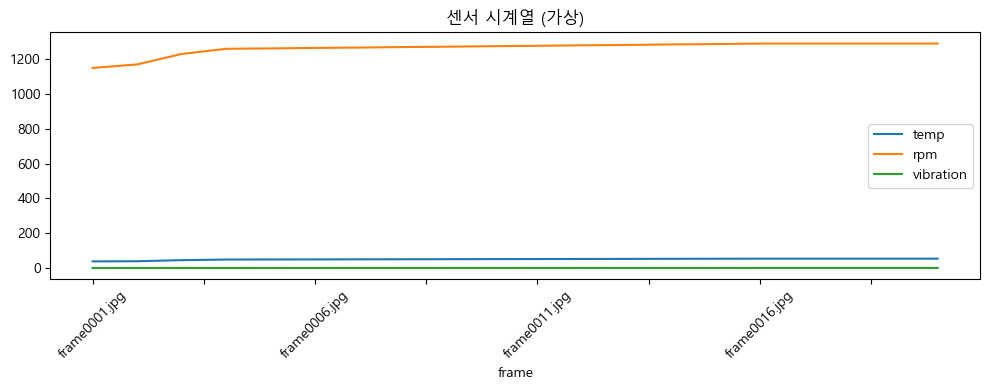

In [5]:
# 처음 4프레임은 고정 시드 값 (실습 시나리오: 점진적 이상)
SEED_ROWS = [
    {"frame": "frame0001.jpg", "machine": "M01", "temp": 38.2, "rpm": 1150, "vibration": 0.08, "current": 2.9, "speed": 0.95, "status": "Normal"},
    {"frame": "frame0002.jpg", "machine": "M01", "temp": 39.1, "rpm": 1170, "vibration": 0.10, "current": 3.0, "speed": 0.95, "status": "Normal"},
    {"frame": "frame0003.jpg", "machine": "M01", "temp": 45.3, "rpm": 1230, "vibration": 0.31, "current": 3.8, "speed": 0.96, "status": "Warning"},
    {"frame": "frame0004.jpg", "machine": "M01", "temp": 48.8, "rpm": 1260, "vibration": 0.45, "current": 4.1, "speed": 0.98, "status": "Fault"},
]
COLUMNS = ["frame", "machine", "temp", "rpm", "vibration", "current", "speed", "status"]


def generate_sensor_csv(frame_files: list[Path]) -> pd.DataFrame:
    """프레임 목록에 맞춰 sensor.csv를 생성하고 DataFrame을 반환합니다."""
    random.seed(42)  # 재현 가능한 가상 데이터
    rows = []
    for i, path in enumerate(sorted(frame_files)):
        if i < len(SEED_ROWS) and SEED_ROWS[i]["frame"] == path.name:
            rows.append(SEED_ROWS[i])
        else:
            # 5번째 프레임부터: Fault 시드 기준으로 수치가 서서히 악화
            base = SEED_ROWS[3]
            progress = min((max(i, 3) - 3) / 12.0, 1.0)
            rows.append({
                "frame": path.name, "machine": "M01",
                "temp": round(base["temp"] + progress * 5, 1),
                "rpm": int(base["rpm"] + progress * 30),
                "vibration": round(base["vibration"] + progress * 0.2, 2),
                "current": round(base["current"] + progress * 0.5, 1),
                "speed": round(min(base["speed"] + progress * 0.02, 1.0), 2),
                "status": "Fault" if progress < 0.4 else "Warning",
            })
    with SENSOR_CSV.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=COLUMNS)
        writer.writeheader()
        writer.writerows(rows)
    return pd.DataFrame(rows)


sensor_df = generate_sensor_csv(frame_paths)
display(sensor_df)
setup_korean_matplotlib()
sensor_df.plot(x="frame", y=["temp", "rpm", "vibration"], figsize=(10, 4), rot=45)
plt.title("센서 시계열 (가상)")
plt.tight_layout()
plt.show()

## 3. SigLIP2 Embedding → ChromaDB 저장

SigLIP2 So400M으로 이미지 임베딩을 계산하고, **센서 메타데이터**와 함께 ChromaDB에 저장합니다.

| 기술 | 설명 |
|------|------|
| **SigLIP2** | Google의 비전-언어 모델. 이미지와 텍스트를 **같은 벡터 공간**에 매핑 (한글 쿼리 지원) |
| **임베딩** | 이미지/텍스트를 고정 길이 실수 벡터(예: 1152차원)로 변환 |
| **L2 정규화** | 벡터 길이를 1로 맞춤 → 코사인 유사도 = 내적과 동일하게 계산 |
| **ChromaDB** | 벡터 DB. `PersistentClient`로 디스크에 저장, 재실행해도 유지 |
| **HNSW + cosine** | 근사 최근접 탐색. 쿼리 벡터와 가장 가까운 Top-k 프레임을 빠르게 찾음 |

**메타데이터 연계**: 벡터만 저장하면 "몇 번 프레임인지, 온도가 얼마인지" 알 수 없습니다.
`metadatas=`에 센서 값을 함께 넣어 검색 결과에서 바로 확인합니다.

In [6]:
class SigLIP2Encoder:
    """SigLIP2 So400M — 이미지/텍스트 임베딩 (다국어·한글 검색용)."""

    def __init__(self, model_id: str = SIGLIP2_MODEL_ID):
        dtype = torch.float16 if device == "cuda" else torch.float32
        self.model = AutoModel.from_pretrained(model_id, torch_dtype=dtype).to(device).eval()
        self.processor = AutoProcessor.from_pretrained(model_id)  # 이미지 리사이즈·토큰화
        print(f"SigLIP2 로딩 완료: {model_id} ({device})")

    @staticmethod
    def _pool(output):
        """transformers 버전에 따라 Tensor 또는 pooler_output 반환."""
        if isinstance(output, torch.Tensor):
            return output
        return output.pooler_output

    @torch.no_grad()  # 추론 시 gradient 비활성 → 메모리·속도 절약
    def encode_images(self, images: list) -> np.ndarray:
        inputs = self.processor(images=images, return_tensors="pt").to(device)
        feats = self._pool(self.model.get_image_features(**inputs))
        feats = feats / feats.norm(dim=-1, keepdim=True)  # L2 정규화
        return feats.cpu().numpy()

    @torch.no_grad()
    def encode_texts(self, texts: list[str]) -> np.ndarray:
        # 학습 시와 동일: max_length=64, 패딩·잘림 적용
        inputs = self.processor(text=texts, padding="max_length", truncation=True,
                                max_length=64, return_tensors="pt").to(device)
        feats = self._pool(self.model.get_text_features(**inputs))
        feats = feats / feats.norm(dim=-1, keepdim=True)
        return feats.cpu().numpy()


siglip_encoder = SigLIP2Encoder()

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

SigLIP2 로딩 완료: google/siglip2-so400m-patch14-384 (cuda)


In [7]:
# ChromaDB 클라이언트 — path에 SQLite + 벡터 인덱스가 영구 저장됨
chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))
try:
    chroma_client.delete_collection(COLLECTION_NAME)  # 재실행 시 깨끗하게 재구축
except Exception:
    pass

collection = chroma_client.create_collection(
    name=COLLECTION_NAME,
    metadata={"hnsw:space": "cosine"},  # 거리 척도: 코사인 (정규화 벡터에 적합)
)

frames = sorted(FRAMES_DIR.glob("frame*.jpg"))
for i in tqdm(range(0, len(frames), SIGLIP2_BATCH_SIZE), desc="ChromaDB 인덱싱"):
    batch = frames[i : i + SIGLIP2_BATCH_SIZE]
    images = [Image.open(p).convert("RGB") for p in batch]
    embeddings = siglip_encoder.encode_images(images)

    ids, metas = [], []
    for p in batch:
        row = sensor_df[sensor_df["frame"] == p.name].iloc[0]
        ids.append(p.stem)  # 문서 ID: frame0001 (확장자 제외)
        metas.append({
            "frame": p.name,
            "local_path": str(p.resolve()),  # 검색 후 이미지 열기·VLM 입력용
            "machine": row["machine"],
            "temp": float(row["temp"]),
            "rpm": int(row["rpm"]),
            "vibration": float(row["vibration"]),
            "current": float(row["current"]),
            "speed": float(row["speed"]),
            "status": row["status"],
        })
    collection.add(ids=ids, embeddings=embeddings.tolist(), metadatas=metas)

print(f"ChromaDB 인덱싱 완료: {collection.count()}개 벡터")

ChromaDB 인덱싱: 100%|██████████| 3/3 [00:03<00:00,  1.19s/it]

ChromaDB 인덱싱 완료: 20개 벡터


## 4. 텍스트 검색 (SigLIP2 + ChromaDB) + 센서 메타 연계

한글(또는 영어) **텍스트 쿼리**를 SigLIP2 텍스트 인코더로 벡터화한 뒤,
ChromaDB에서 코사인 유사도 기준 **Top-k** 프레임을 검색합니다.

```
"컨베이어 벨트 이상 상태"  →  SigLIP2 text embedding
                                    ↓
              ChromaDB에서 image embedding과 비교
                                    ↓
              유사도 높은 frame0003.jpg ... + 센서 메타
```

| 용어 | 설명 |
|------|------|
| **similarity** | `1 - distance`. 1에 가까울수록 쿼리와 의미적으로 유사 |
| **Top-k** | 상위 k개 결과만 반환 (기본 4) |
| **메타데이터** | 검색된 각 프레임의 temp, rpm, status 등 — CSV와 동일 값 |

In [8]:
def search_conveyor(query: str, top_k: int = TOP_K) -> list[dict]:
    """텍스트 쿼리 → SigLIP2 → ChromaDB Top-k 검색."""
    query_emb = siglip_encoder.encode_texts([query])[0].tolist()
    results = collection.query(
        query_embeddings=[query_emb],
        n_results=top_k,
        include=["metadatas", "distances"],
    )
    hits = []
    for j in range(len(results["ids"][0])):
        meta = results["metadatas"][0][j]
        hits.append({
            "rank": j + 1,
            "id": results["ids"][0][j],
            "similarity": 1 - results["distances"][0][j],  # cosine distance → similarity
            "metadata": meta,
        })
    return hits


def show_search_results(hits: list[dict]):
    """검색 결과 이미지 그리드 + 센서 메타데이터 테이블 출력."""
    setup_korean_matplotlib()
    n = len(hits)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, hit in zip(axes, hits):
        meta = hit["metadata"]
        img = Image.open(meta["local_path"])
        ax.imshow(img)
        ax.set_title(
            f"{meta['frame']}\n유사도 {hit['similarity']:.3f}\n"
            f"{meta['status']} | {meta['temp']}°C | RPM {meta['rpm']}"
        )
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    print("\n[센서 메타데이터]")
    display(pd.DataFrame([h["metadata"] for h in hits]))

Query: 컨베이어 벨트 이상 상태


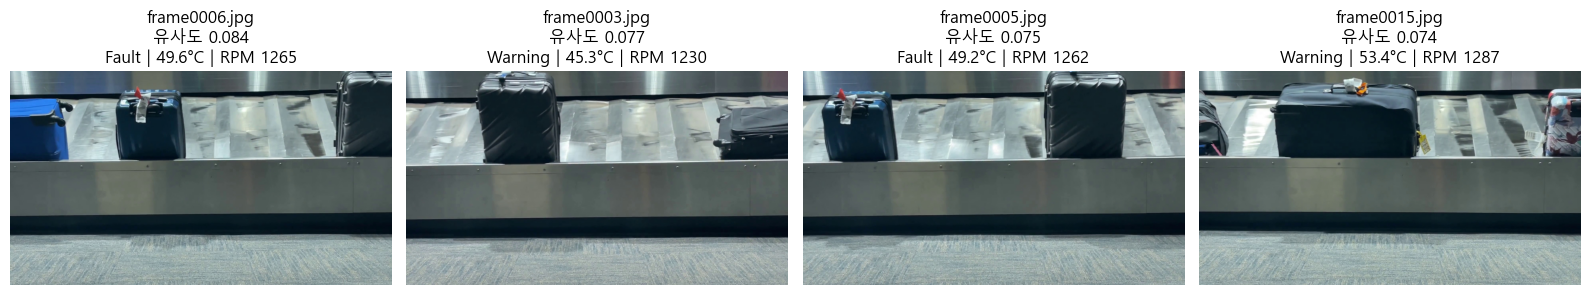


[센서 메타데이터]


,status,local_path,rpm,current,temp,speed,vibration,machine,frame
0,Fault,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,1265,4.2,49.6,0.98,0.48,M01,frame0006.jpg
1,Warning,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,1230,3.8,45.3,0.96,0.31,M01,frame0003.jpg
2,Fault,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,1262,4.1,49.2,0.98,0.47,M01,frame0005.jpg
3,Warning,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,1287,4.6,53.4,1.00,0.63,M01,frame0015.jpg


In [9]:
QUERY = "컨베이어 벨트 이상 상태"
hits = search_conveyor(QUERY, top_k=TOP_K)
print(f"Query: {QUERY}")
show_search_results(hits)

## 5. Qwen3-VL — 이미지 + 센서 종합 분석

검색된 **모든** Top-k 프레임과 센서 수치를 Qwen3-VL에 전달하여 이상 징후를 분석합니다.

| 기술 | 설명 |
|------|------|
| **Qwen3-VL** | Alibaba 시각-언어 모델(VLM). 이미지를 "보고" 한국어로 설명·추론 |
| **VLM 입력** | 채팅 형식 — 이미지 여러 장 + 텍스트 프롬프트를 한 메시지로 전달 |
| **1장씩 분석** | VRAM 절약. 4장을 한 번에 넣으면 12GB GPU에서 OOM 발생 가능 |

> **VRAM 절약 (12GB GPU 기준)**
> 1. **검색(이전 단계) 완료 후** 아래 셀을 실행하세요.
> 2. SigLIP2를 GPU에서 해제한 뒤 Qwen3-VL을 로드합니다. (두 모델 동시 상주 방지)
> 3. 이미지는 **1장씩 전부** 분석한 뒤 마지막에 종합합니다.

**커널 OOM 발생 시:** `Kernel → Restart` 후 환경 설정 → 프레임·센서·ChromaDB·검색 → Qwen 순서로 다시 실행하세요.

In [10]:
def free_siglip_gpu():
    """Qwen3-VL 로드 전 SigLIP2 GPU 메모리 해제."""
    global siglip_encoder
    if siglip_encoder is not None:
        del siglip_encoder.model
        del siglip_encoder.processor
        del siglip_encoder
        siglip_encoder = None
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()  # CUDA 캐시 비우기
    print("SigLIP2 GPU 메모리 해제 완료")


free_siglip_gpu()

print(f"Qwen3-VL 로딩: {QWEN_MODEL_ID}")
qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(
    QWEN_MODEL_ID,
    torch_dtype=torch.bfloat16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None,  # GPU 자동 배치
    attn_implementation="sdpa",  # Scaled Dot-Product Attention (메모리 효율)
    low_cpu_mem_usage=True,
)
qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
print("로딩 완료.")

# RTX 3060 : 다운로드 약 6분 소요

SigLIP2 GPU 메모리 해제 완료
Qwen3-VL 로딩: Qwen/Qwen3-VL-2B-Instruct


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

로딩 완료.


In [11]:
def run_qwen_vl(image_paths: list[str], prompt: str, max_new_tokens: int = 128) -> str:
    """이미지 1~2장 + 텍스트로 Qwen3-VL 추론 (VRAM 절약)."""
    # Windows: file:// URL 대신 PIL Image 객체 전달 (호환성)
    content = [{"type": "image", "image": Image.open(p).convert("RGB")} for p in image_paths]
    content.append({"type": "text", "text": prompt})
    messages = [{"role": "user", "content": content}]

    inputs = qwen_processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    )
    inputs = inputs.to(qwen_model.device)
    with torch.no_grad():
        generated = qwen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            repetition_penalty=1.15,  # 같은 단어 반복 억제
            do_sample=False,          # greedy decoding (결정적 출력)
        )
    # 입력 토큰 제거 → 새로 생성된 부분만 디코딩
    trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated)]
    text = qwen_processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()
    del inputs, generated
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return text


def analyze_with_sensor(hits: list[dict], query: str) -> str:
    """검색된 모든 프레임을 1장씩 분석 후 종합 (OOM 방지)."""
    per_frame = []

    for i, h in enumerate(hits, 1):
        meta = h["metadata"]
        path = meta["local_path"]
        prompt = (
            f"{query}\n\n"
            f"[센서] {meta['frame']}: temp={meta['temp']}°C, rpm={meta['rpm']}, "
            f"vibration={meta['vibration']}, current={meta['current']}A, status={meta['status']}\n\n"
            "이 한 장의 이미지와 센서 수치만 보고 이상 징후를 2~3문장 한국어로 설명하세요."
        )
        summary = run_qwen_vl([path], prompt, max_new_tokens=100)
        per_frame.append(f"이미지 {i} ({meta['frame']}): {summary}")
        print(f"  프레임 {i}/{len(hits)} 분석 완료")

    # 종합 단계: status가 가장 심각한(Fault) 프레임 이미지 1장 + 전체 텍스트 요약
    status_rank = {"Normal": 0, "Warning": 1, "Fault": 2}
    worst = max(hits, key=lambda h: status_rank.get(h["metadata"]["status"], 0))
    summaries = "\n".join(per_frame)
    final_prompt = (
        f"{query}\n\n[프레임별 분석 — 총 {len(hits)}장]\n{summaries}\n\n"
        "위 내용을 종합하여 이상 여부, 가능한 원인, 권장 조치를 4~6문장 한국어로 설명하세요."
    )
    return run_qwen_vl([worst["metadata"]["local_path"]], final_prompt, max_new_tokens=200)

In [12]:
ANALYZE_QUERY = "컨베이어 벨트에서 이상 징후가 보이는 프레임을 찾고 원인을 분석하세요."
print("=" * 60)
print("[Qwen3-VL 분석]")
print("=" * 60)
analysis = analyze_with_sensor(hits, ANALYZE_QUERY)
print(analysis)

# RTX 3060 : 약 1분 소요

[Qwen3-VL 분석]
  프레임 1/4 분석 완료
  프레임 2/4 분석 완료
  프레임 3/4 분석 완료
  프레임 4/4 분석 완료
컨베이어 벨트에는 **정상적인 동작**과 함께 **전류 값이 상승**하며 **진동이 증가**하는 현상을 보이고 있어, **기계적 오작동** 또는 **부품 고장**의 가능성이 존재합니다. 이미지 2와 4에서 전류 상승과 진동 증가가 반복되므로, **제어 시스템 오작동** 또는 **냉각 장비의 불량**이 지속될 수 있음을 의미합니다. 이러한 경우, **전력 공급 확인**, **제어 단말기 점검**, 그리고 **냉각 장비의 검토** 등을 통해 원인을 파악해야 합니다. 만약 문제가 계속 진행된다면, **기계적 점검**과 **조종자 대응**이 필요할 것입니다.


## 6. Visual RAG 통합 파이프라인

검색 → 센서 연계 → Qwen3-VL 분석을 한 함수로 묶습니다.

`visual_rag_conveyor()` 한 번 호출로 end-to-end 실행:

1. (필요 시) SigLIP2 재로딩
2. 텍스트 쿼리로 ChromaDB 검색 + 시각화
3. SigLIP2 GPU 해제
4. Qwen3-VL로 전체 프레임 분석

| 매개변수 | 설명 |
|----------|------|
| `query` | 한글 검색·분석 질문 |
| `top_k` | 검색·분석할 프레임 수 |
| `run_analysis=False` | 검색만 수행 (Qwen 생략) |

In [13]:
def visual_rag_conveyor(query: str, top_k: int = TOP_K, run_analysis: bool = True):
    """한글 Query → SigLIP2 → ChromaDB Top-k → (선택) Qwen3-VL + 센서 분석"""
    global siglip_encoder
    if siglip_encoder is None:
        # Qwen 로딩 후 SigLIP2가 해제된 경우 — 검색을 위해 다시 로드
        print("SigLIP2 재로딩 (검색용)...")
        siglip_encoder = SigLIP2Encoder()

    print(f"[Query] {query}")
    hits = search_conveyor(query, top_k=top_k)
    show_search_results(hits)

    if run_analysis:
        if qwen_model is None:
            raise RuntimeError("먼저 Qwen3-VL 로딩 셀을 실행하세요.")
        free_siglip_gpu()  # 분석 전 검색 모델 메모리 반환
        print("\n" + "=" * 60)
        print("[Qwen3-VL 분석 결과]")
        print("=" * 60)
        result = analyze_with_sensor(hits, query)
        print(result)
        return {"hits": hits, "analysis": result}
    return {"hits": hits}

SigLIP2 재로딩 (검색용)...


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

SigLIP2 로딩 완료: google/siglip2-so400m-patch14-384 (cuda)
[Query] 컨베이어 벨트 진동 이상 및 과열 징후


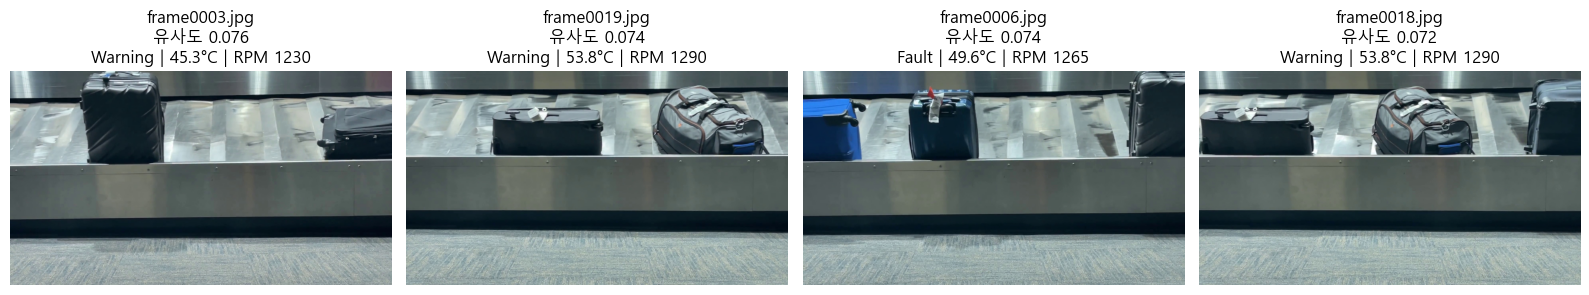


[센서 메타데이터]


,temp,vibration,frame,status,speed,local_path,current,rpm,machine
0,45.3,0.31,frame0003.jpg,Warning,0.96,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,3.8,1230,M01
1,53.8,0.65,frame0019.jpg,Warning,1.00,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,4.6,1290,M01
2,49.6,0.48,frame0006.jpg,Fault,0.98,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,4.2,1265,M01
3,53.8,0.65,frame0018.jpg,Warning,1.00,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,4.6,1290,M01


SigLIP2 GPU 메모리 해제 완료

[Qwen3-VL 분석 결과]
  프레임 1/4 분석 완료
  프레임 2/4 분석 완료
  프레임 3/4 분석 완료
  프레임 4/4 분석 완료
컨베이어 벨트는 일반적으로 정상적인 운행 상태를 유지하지만, **이미지 2**에서 '경보' 상태가 나타난 점에서 **기계적 오작동 또는 전기적 부하 증가**(예: 전류 4.6A) 가능성 있음.  
**이유**: 전류가 급증하면 열량이 증가하여 온도 상승 → **진동 amplitudes**가 증가하거나, **온도가 상승**하는 현상이 관찰됨.  
**권장 조치**: 즉시 전력 공급 장비 점검 및 **냉각 시스템 확인**, **전류 감지 장치 검토**, 그리고 **기계적 부분(예: 휠, 드라이브 모터)**의 외관 및 작동 상태 점검 필요함.


In [14]:
# end-to-end 실행 예제
result = visual_rag_conveyor("컨베이어 벨트 진동 이상 및 과열 징후", top_k=4)

## 요약

| 단계 | 내용 |
|------|------|
| OpenCV | 프레임 추출 (`frame0001.jpg` ...) |
| sensor.csv | 가상 센서 생성 (frame ↔ temp/rpm/status) |
| SigLIP2 + ChromaDB | 임베딩 + 센서 메타 저장 |
| 검색 | 한글 텍스트 → Top-k + 시각화 |
| Qwen3-VL | 이미지·센서 종합 이상 분석 |
| `visual_rag_conveyor()` | 위 전체를 한 함수로 실행 |

**핵심**: ChromaDB 메타데이터에 센서 값을 함께 저장하여, 검색 결과마다 이미지와 센서가 자동으로 연계됩니다.

### Retriever vs Generator

- **Retriever (SigLIP2 + ChromaDB)**: 질문에 맞는 프레임을 **빠르게 찾기**
- **Generator (Qwen3-VL)**: 찾은 프레임을 **이해하고 설명하기** (VRAM 많이 사용)

실무에서는 Retriever로 후보를 좁힌 뒤, Generator는 소수 프레임만 분석하는 것이 일반적입니다.